<a href="https://colab.research.google.com/github/giraldoal/datos12024/blob/main/Pr%C3%A1ctica_librer%C3%ADa_PDFQuery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PDFQuery
[PDFQuery](https://pypi.org/project/pdfquery/) es una envoltura ligera alrededor de [pdfminer](https://pypi.org/project/pdfminer/), [lxml](https://pypi.org/project/lxml/) y [pyquery](https://pypi.org/project/pyquery/). Está diseñado para extraer datos de forma fiable a partir de conjuntos de archivos PDF con la menor cantidad de código posible.

## Instalación

In [ ]:
!pip install pdfquery

## Leer y convertir un pdf a formato XML
Para poder extraer información de archivos PDF, es necesario convertirlos a un formato que pueda ser procesado fácilmente por máquinas y humanos. En este sentido, el formato XML es una opción comúnmente utilizada, ya que permite la estructuración de la información y la inclusión de metadatos.

Una vez que el archivo PDF es convertido a formato XML, podemos acceder a los datos de forma más eficiente y sistemática. El archivo XML contiene no solo la información de los elementos del documento, sino también los metadatos asociados con cada página, lo que permite una mayor flexibilidad y facilidad de uso para la extracción de datos. Además, el formato XML es altamente compatible con las herramientas de procesamiento de datos y de análisis, lo que lo convierte en una opción versátil para la extracción de información de archivos PDF.

In [ ]:
#@markdown 1. Descargamos el archivo pdf con el nombre "ejemplo.pdf" al entorno de trabajo
url_pdf = "https://www.unibague.edu.co/images/centrodeespanol/Documentos/Gua-de-Publicaciones-de-Ediciones-Unibagu-Versin-aprobada-julio-2019-1.pdf" #@param {type: "string"}

!wget {url_pdf} --no-check-certificate --output-document ejemplo.pdf

--2026-03-30 03:24:13--  https://www.unibague.edu.co/images/centrodeespanol/Documentos/Gua-de-Publicaciones-de-Ediciones-Unibagu-Versin-aprobada-julio-2019-1.pdf
Resolving www.unibague.edu.co (www.unibague.edu.co)... 168.197.69.117
Connecting to www.unibague.edu.co (www.unibague.edu.co)|168.197.69.117|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 757719 (740K) [application/pdf]
Saving to: ‘ejemplo.pdf’

ejemplo.pdf         100%[===================>] 739.96K  1.12MB/s    in 0.6s    

2026-03-30 03:24:15 (1.12 MB/s) - ‘ejemplo.pdf’ saved [757719/757719]



In [ ]:
#@markdown Lectura y conversion a XML, el resultado se guarda como "ejemplo.xml"
import pdfquery as pq
#Leer el archivo PDF
pdf = pq.PDFQuery('ejemplo.pdf')
pdf.load()

#Convertir el PDF a XML
pdf.tree.write('ejemplo.xml', pretty_print=True)
pdf

## Extracción de datos
La idea básica es transformar un documento PDF en un árbol de elementos para que podamos encontrar elementos con selectores tipo JQuery utilizando pyquery. Supongamos que intentamos extraer los títulos que inician con "Guía" en cada PDF:

In [ ]:
label = pdf.pq('LTTextBoxHorizontal:contains("Guía")')

# Con la función text() se extrae el contenido de texto de la etiqueta extraida
print("Título:", label.text())

Título: Guía de Publicaciones de Ediciones Unibagué


### Conjunto de datos formateado
Ahora vamos a extraer y formatear un montón de datos de una sola vez:

In [ ]:
pdf.extract( [
  ('with_parent','LTPage[pageid="1"]'), # Indica que se busca en la página con id 1
  ('with_formatter', 'text'), # Extrae el texto de la etiqueta encontrada

  # Especificando las coordenadas de la caja del contenido
  ('titulo_1', 'LTTextBoxHorizontal:in_bbox("170,690,446,705")'),
  # Especificando que el atributo index es 1
  ('pagina_1_linea_1', 'LTTextBoxHorizontal[index="1"]'),

  ('with_parent','LTPage[pageid="2"]'),
  # No se especificó como operar con la etiqueta seleccionada, asi que
  # se pasa una función que indica lo que se debe hacer
  ('titulo_2', 'LTTextBoxHorizontal:contains("formato digital")', lambda match: match.text()[:30]+"..."),
  ('Número_palabras', 'LTTextBoxHorizontal[index="13"]', lambda match: int(match.text().split(" ")[7]))
 ])

{'titulo_1': 'Guía de Publicaciones de Ediciones Unibagué',
 'pagina_1_linea_1': 'Presentamos la siguiente guía con el fin de ofrecer a los autores interesados en la publicación de',
 'titulo_2': 'Atributos formales para la pre...',
 'Número_palabras': 200}

## Modelo de datos
PDFQuery funciona cargando un PDF como un formato pdfminer, convirtiendo el formato en un etree con `lxml.etree`, y luego aplicando una envoltura pyquery. Las tres bibliotecas subyacentes están expuestas, por lo que puede utilizar cualquiera de sus interfaces para obtener los datos que desee.

En primer lugar, pdfminer abre el documento y lee su formato. Puedes acceder al documento pdfminer en `pdf.doc`:

In [ ]:
pdf.doc

In [ ]:
pdf.doc.catalog

{'Type': /'Catalog',
 'Pages': <PDFObjRef:2>,
 'Lang': b'en-US',
 'StructTreeRoot': <PDFObjRef:124>,
 'MarkInfo': {'Marked': True},
 'OutputIntents': [{'Type': /'OutputIntent',
   'S': /'GTS_PDFA1',
   'OutputConditionIdentifier': b'sRGB',
   'RegistryName': b'http://www.color.org',
   'Info': b'Creator: HP     Manufacturer:IEC    Model:sRGB',
   'DestOutputProfile': <PDFObjRef:1141>}],
 'Metadata': <PDFObjRef:1142>}

A continuación, el diseño se convierte en un lxml.etree con una envoltura pyquery. Después de llamar a `pdf.load()` (con diferencia la operación más costosa del proceso), puedes acceder al etree en `pdf.tree`, y a la envoltura pyquery en `pdf.pq`:

In [ ]:
# pdf.load() # no se ejecuta porque ya se hizo antes
pdf.tree

In [ ]:
# Extrae las paginas
labels = pdf.tree.xpath('//*/LTPage')
label[0]

<Element LTTextBoxHorizontal at 0x79b96c261950>

In [ ]:
# Utilizando pyquery
labels =pdf.pq('LTPage[pageid="2"] :contains("200")')
for i, l in enumerate(labels):
  print("Etiqueta", l.tag," (%i):"%i,l.text[:30],"...")

## Cargar solo lo necesario
Ahorrará tiempo y memoria si llamamos a `load()` sólo con los números de página que necesitamos. Por ejemplo:

In [ ]:
pdf = pq.PDFQuery('ejemplo.pdf')
pdf.load(0, 2, 3, list(range(4,8)))

La llamada inicial a `pdf.load()` se ejecuta muy lentamente, porque la biblioteca pdfminer subyacente tiene que comparar cada elemento de la página con cualquier otro elemento. Consulte la sección *Almacenamiento en caché*  para evitar esto en las siguientes ejecuciones.

Bajo el aspecto interno, pdf.tree es básicamente una representación XML del árbol de formato generado por pdfminer.pdffinterp. Por defecto, el árbol se procesa para combinar nodos de caracteres individuales, eliminar espacios extra y ordenar el árbol espacialmente. Siempre se puede volver al objeto en formato original de pdfminer desde un elemento obtenido por xpath o pyquery:

In [ ]:
labels =pdf.pq('LTTextBoxHorizontal:contains("Guía")')
labels[0].layout

<LTTextBoxHorizontal(0) 170.090,690.907,445.570,704.947 'Guía de Publicaciones de Ediciones Unibagué \n'>

## Búsquedas
Los PDF son internamente desordenados, por lo que no suele ser útil encontrar cosas basándose en la estructura del documento o en las clases de elementos como se haría con HTML. En su lugar, los selectores más fiables son las etiquetas estáticas de la página, que puede encontrar buscando su contenido textual y su ubicación física en la página. Las coordenadas PDF se dan en puntos (72 por pulgada) empezando por la esquina inferior izquierda. PDFMiner (y por lo tanto PDFQuery) describe las ubicaciones de las páginas en términos de cajas delimitadoras, o bboxes. Un bbox consta de cuatro coordenadas: la X y la Y de la esquina inferior izquierda, y la X y la Y de la esquina superior derecha. De tal forma que:
- Esquina inferior izquierda es denotada como `x0, y0`.
- Esquina superior derecha es denotada como `x1, y1`

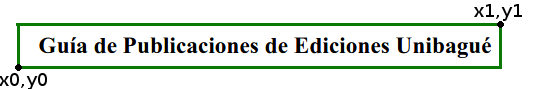

In [ ]:
label = pdf.pq('LTTextBoxHorizontal:contains("Guía")')

izquierda = float(label.attr('x0'))
abajo = float(label.attr('y0'))
derecha = float(label.attr('x1'))
arriba = float(label.attr('y1'))

print("Izquierda (x0):",izquierda)
print("Abajo (y0):",abajo)
print("Derecha (x1):",derecha)
print("Arriba (y1):",arriba)

Izquierda (x0): 170.09
Abajo (y0): 690.907
Derecha (x1): 445.57
Arriba (y1): 704.947


Si está extrayendo texto que se encuentra siempre en el mismo lugar de la página, la forma más sencilla es utilizar la herramienta de medición de Acrobat Pro, Photoshop o una herramienta similar para medir distancias (en puntos) desde la esquina inferior izquierda de la página y utilizar esas distancias para crear un selector como :`in_bbox("x0,y0,x1,y1")` (más adelante encontrará más información sobre `in_bbox`).

Si está extrayendo texto que podría estar en diferentes partes de la página, se aplica la misma técnica básica, pero primero tendrás que encontrar un elemento con texto consistente que aparezca a una distancia consistente del texto que desea, y luego calcular el bbox en relación con ese elemento.

Si ambos fallan, lo mejor es guardar el xml usando `pdf.tree.write(filename, pretty_print=True)`, y ver si puedes encontrar alguna otra estructura, etiquetas o elementos que identifiquen de forma fiable la parte que estás buscando (Si ejecutaste todas las celdas previas ya debe existir un archivo "ejemplo.xml" en `/content`). Esto también es útil cuando intentas averiguar por qué tus selectores no coinciden.

## Selectores personalizados
La versión de pyquery devuelta por `pdf.pq` admite algunos selectores específicos de PDF para encontrar elementos por ubicación en la página.

- `:in_bbox("x0,y0,x1,y1")` -- Coincide sólo con los elementos que caben completamente dentro de la bbox dada.
- `:overlaps_bbox("x0,y0,x1,y1")` -- Coincide con cualquier elemento que se superponga a la bbox dada.

### Ejemplo
En el siguiente ejemplo podemos experimentar ajustar la caja de búsqueda

In [ ]:
#@markdown Utilizamos el tag o etiqueta `LTTextBoxHorizontal` para
#@markdown extraer una linea de texto

# Acceso a los datos utilizando coordenadas
# Especificamos las coordenadas
izquierda = 150 #@param {type: "number"}
abajo = 690.907 #@param {type: "number"}
derecha = 445.57 #@param {type: "number"}
arriba = 704.947 #@param {type: "number"}
valores_por_defecto = True #@param {type:"boolean"}

# Ajusta si se toman los valores por defecto
if valores_por_defecto:
  izquierda = 170.09
  abajo = 690.907
  derecha = 445.57
  arriba = 704.947

# Ajusta el string para realizar la consulta
consulta = 'LTTextLineHorizontal:in_bbox('
consulta += '"%s")'%str( (izquierda,abajo,derecha,arriba))[1:-1]

print("Consulta:  ",consulta)
resultado = pdf.pq(consulta).text()

print("Resultado: ", resultado)

Consulta:   LTTextLineHorizontal:in_bbox("170.09, 690.907, 445.57, 704.947")
Resultado:  Guía de Publicaciones de Ediciones Unibagué


## Almacenamiento en caché
PDFQuery acepta un argumento de caché opcional que almacenará los resultados del análisis del PDF, de modo que las ejecuciones posteriores en el mismo archivo serán mucho más rápidas. Por ejemplo:

In [ ]:
from pdfquery.cache import FileCache
pq.PDFQuery("ejemplo.pdf", parse_tree_cacher=FileCache("/tmp/"))

## Extracción masiva de datos
A menudo vas a querer obtener un montón de datos diferentes de un PDF, utilizando el mismo proceso repetitivo: (1) encontrar un elemento del documento utilizando un selector pyquery o Xpath; (2) analizar el texto resultante; y (3) almacenarlo en un dict para ser utilizado más tarde.

El método `extract` simplifica ese proceso. Dada una lista de palabras clave y selectores:

In [ ]:
pdf.extract( [
  ('with_parent','LTPage[pageid="1"]'), # Indica que se busca en la página con id 1
  ('with_formatter', 'text'), # Extrae el texto de la etiqueta encontrada

  # Especificando las coordenadas de la caja del contenido
  ('titulo_1', 'LTTextBoxHorizontal:in_bbox("170,690,446,705")'),
  # Especificando que el atributo index es 1
  ('pagina_1_linea_1', 'LTTextBoxHorizontal[index="3"]'),

  ('with_parent','LTPage[pageid="2"]'),
  # No se especificó como operar con la etiqueta seleccionada, asi que
  # se pasa una función que indica lo que se debe hacer
  ('titulo_2', 'LTTextBoxHorizontal:contains("Márgenes")', lambda match: match.text()+"..."),
  ('puntos', 'LTTextBoxHorizontal[index="5"]', lambda match:int(match.text().split("(")[1][:2]))
 ])

{'titulo_1': 'Guía de Publicaciones de Ediciones Unibagué',
 'pagina_1_linea_1': 'iniciar el proceso de edición de sus artículos o libros. Las indicaciones acá contenidas se refieren',
 'titulo_2': '...',
 'puntos': 10}

### Objetivo de la busqueda
Por defecto, extract busca en todo el árbol (o en la parte del documento cargado anteriormente mediante `load()`, si se limitó a páginas concretas). Si queremos limitar la búsqueda a una parte del árbol obtenida anteriormente con `pdf.pq()`, la introducimos como segundo parámetro después de la lista de búsquedas.

### Funciones de formato
El ejemplo anterior contiene un tercer parámetro opcional: una función de formato. A la función de formato se le pasará el resultado de la coincidencia de pyquery, por lo que `lambda match: match.text()+"..."` devolverá el contenido del texto de los elementos coincidentes agregando `...`.

### Funciones de filtrado
En lugar de una cadena, el selector puede ser una función de filtrado que devuelva un booleano:

In [ ]:
def big_elements():
    return float(this.get('width',0)) * float(this.get('height',0)) > 40000
pdf.extract([('big', big_elements)])

{'big': [<LTPage>, <LTPage>, <LTPage>, <LTPage>, <LTPage>, <LTPage>, <LTPage>]}

### Palabras clave
La función `extract` también busca dos palabras clave especiales en la lista de búsquedas que establecen valores predeterminados para las búsquedas que aparecen a continuación. Podemos incluir la misma palabra clave especial más de una vez para cambiar la configuración, como se demuestra en el ejemplo inicial de la sección *Extracción masiva de datos*. Las palabras clave son:

- `with_parent`: limita las siguientes búsquedas a los hijos de la búsqueda padre.
- `with_formatter`: establece una función de formato por defecto que será llamada a menos que se proporcione una específica.

Si queremos dejar de filtrar los resultados, se puede utilizar: `('with_formatter', None)`

## Dónde continuar
Para concluir, el contenido de este notebook se ha basado en la documentación de la librería [PDFquery](https://pypi.org/project/pdfquery/), por lo tanto, es una excelente opción para continuar aprendiendo.

También, es posible que para entender mucho mejor la estructura de datos de PDFquery y el modo en que se trabaja sobre ella, sea necesario revisar la documentación de [pdfminer](https://pypi.org/project/pdfminer/), [lxml](https://pypi.org/project/lxml/) y [pyquery](https://pypi.org/project/pyquery/).